# Social Media Sentiment Analysis
### A Data Analytics and Machine Learning Project



This project analyzes social media text data to understand sentiment patterns and builds machine learning models to predict sentiment from tweet text.
The analysis combines exploratory data analysis, natural language processing, and machine learning techniques.


## Problem Statement

Social media platforms generate large volumes of user-generated text that reflect public opinion.
This project aims to analyze sentiment patterns in social media posts and evaluate whether textual features can be used to predict sentiment effectively.


## Objectives

- Analyze sentiment distribution in social media text data
- Explore linguistic differences between positive and negative sentiment
- Perform exploratory data analysis using visualizations
- Build and evaluate machine learning models for sentiment classification
- Address class imbalance and analyze precision–recall trade-offs



## Hypotheses

H1: Positive and negative sentiment tweets exhibit distinct linguistic patterns.  
H2: Tweet length varies between positive and negative sentiment.  
H3: Textual features can be used to predict sentiment using machine learning models.



## Data Description

The dataset consists of social media posts containing tweet text and sentiment labels.
Each tweet is labeled as either positive or negative.
Basic data cleaning was performed by removing missing values before analysis.




In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [5]:
df = pd.read_csv('/content/twitter.csv')
df.head()

,id,label,tweet
0,1,0,@user when a father is dysfunctional and is s...
1,2,0,@user @user thanks for #lyft credit i can't us...
2,3,0,bihday your majesty
3,4,0,#model i love u take with u all the time in ...
4,5,0,factsguide: society now #motivation


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31962 entries, 0 to 31961
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      31962 non-null  int64 
 1   label   31962 non-null  int64 
 2   tweet   31962 non-null  object
dtypes: int64(2), object(1)
memory usage: 749.2+ KB


In [7]:
df.columns

Index(['id', 'label', 'tweet'], dtype='object')

In [8]:
df = df.dropna()
df.shape

(31962, 3)

In [9]:
df['label'].value_counts()


,count
label,
0,29720
1,2242


In [10]:
df['sentiment'] = df['label'].map({
    0: 'Negative',
    1: 'Positive'
})

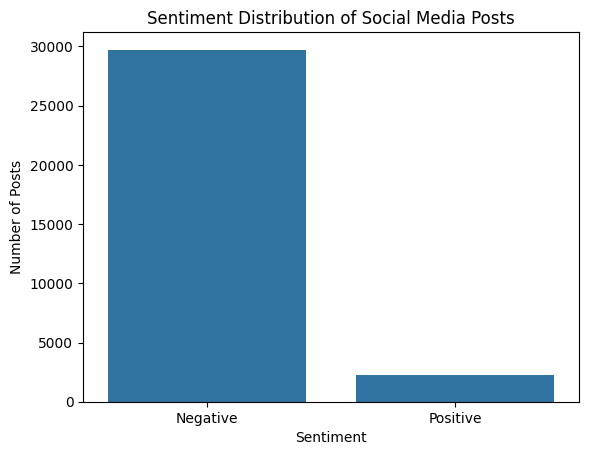

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='sentiment', data=df)
plt.title('Sentiment Distribution of Social Media Posts')
plt.xlabel('Sentiment')
plt.ylabel('Number of Posts')
plt.show()


In [12]:
df['label'].mean()


np.float64(0.07014579813528565)

In [13]:
df[df['sentiment'] == 'Positive']['tweet'].head(3)


,tweet
13,@user #cnn calls #michigan middle school 'buil...
14,no comment! in #australia #opkillingbay #se...
17,retweet if you agree!


In [14]:
df[df['sentiment'] == 'Negative']['tweet'].head(3)


,tweet
0,@user when a father is dysfunctional and is s...
1,@user @user thanks for #lyft credit i can't us...
2,bihday your majesty


In [15]:
brands = ['gucci', 'prada', 'chanel', 'louis vuitton']

def find_brand(text):
    text = text.lower()
    for brand in brands:
        if brand in text:
            return brand
    return 'other'

df['brand'] = df['tweet'].apply(find_brand)


In [16]:
df['brand'].value_counts()


,count
brand,
other,31953
gucci,5
chanel,3
prada,1


In [18]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'[^a-z\s]', '', text)
    return text

df['clean_tweet'] = df['tweet'].apply(clean_text)

In [19]:
from collections import Counter

positive_words = Counter(" ".join(df[df['sentiment']=='Positive']['clean_tweet']).split()).most_common(20)
negative_words = Counter(" ".join(df[df['sentiment']=='Negative']['clean_tweet']).split()).most_common(20)

positive_words, negative_words

([('user', 1861),
  ('the', 841),
  ('a', 615),
  ('to', 567),
  ('you', 462),
  ('of', 461),
  ('is', 433),
  ('in', 430),
  ('and', 364),
  ('are', 327),
  ('amp', 283),
  ('for', 249),
  ('on', 219),
  ('i', 216),
  ('be', 207),
  ('trump', 199),
  ('this', 194),
  ('that', 178),
  ('if', 157),
  ('not', 152)],
 [('user', 15634),
  ('the', 9357),
  ('to', 9277),
  ('a', 5853),
  ('i', 5550),
  ('you', 4994),
  ('and', 4532),
  ('for', 4249),
  ('in', 4233),
  ('is', 3754),
  ('of', 3719),
  ('my', 3620),
  ('love', 2700),
  ('this', 2472),
  ('on', 2432),
  ('with', 2405),
  ('it', 2358),
  ('day', 2278),
  ('be', 2267),
  ('so', 1873)])

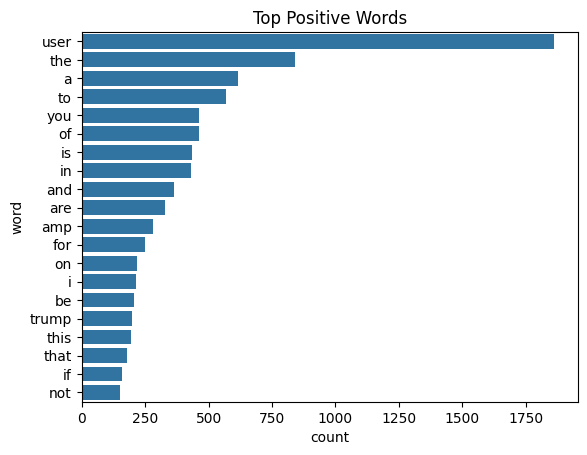

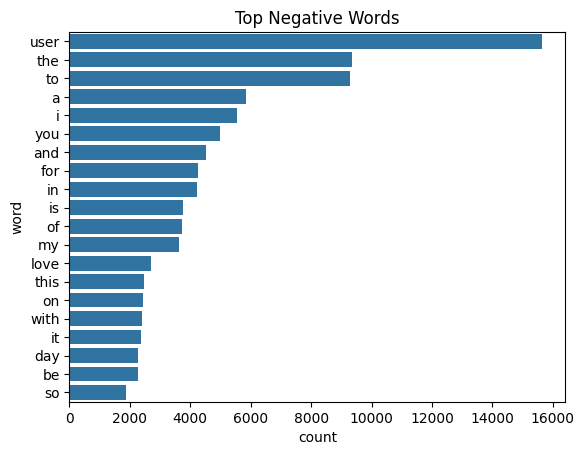

In [20]:
pos_df = pd.DataFrame(positive_words, columns=['word', 'count'])
neg_df = pd.DataFrame(negative_words, columns=['word', 'count'])

sns.barplot(x='count', y='word', data=pos_df)
plt.title('Top Positive Words')
plt.show()

sns.barplot(x='count', y='word', data=neg_df)
plt.title('Top Negative Words')
plt.show()


In [21]:
import nltk
nltk.download('stopwords')

from nltk.corpus import stopwords
stop_words = set(stopwords.words('english'))


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [22]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'[^a-z\s]', '', text)
    words = text.split()
    words = [word for word in words if word not in stop_words]
    return " ".join(words)

df['clean_tweet'] = df['tweet'].apply(clean_text)


In [23]:
positive_words = Counter(
    " ".join(df[df['sentiment']=='Positive']['clean_tweet']).split()
).most_common(20)

negative_words = Counter(
    " ".join(df[df['sentiment']=='Negative']['clean_tweet']).split()
).most_common(20)

positive_words, negative_words


([('user', 1861),
  ('amp', 283),
  ('trump', 199),
  ('libtard', 149),
  ('like', 139),
  ('white', 138),
  ('black', 131),
  ('racist', 103),
  ('politics', 97),
  ('people', 95),
  ('allahsoil', 92),
  ('liberal', 82),
  ('might', 77),
  ('sjw', 74),
  ('women', 72),
  ('new', 71),
  ('obama', 68),
  ('retweet', 67),
  ('dont', 67),
  ('hate', 66)],
 [('user', 15634),
  ('love', 2700),
  ('day', 2278),
  ('happy', 1679),
  ('amp', 1324),
  ('u', 1121),
  ('life', 1120),
  ('im', 1112),
  ('time', 1104),
  ('today', 995),
  ('positive', 931),
  ('thankful', 925),
  ('new', 917),
  ('like', 914),
  ('get', 885),
  ('bihday', 854),
  ('good', 817),
  ('cant', 776),
  ('people', 770),
  ('one', 735)])

In [24]:
df['tweet_length'] = df['clean_tweet'].apply(lambda x: len(x.split()))


In [25]:
df.groupby('sentiment')['tweet_length'].mean()

,tweet_length
sentiment,
Negative,8.279441
Positive,8.989741


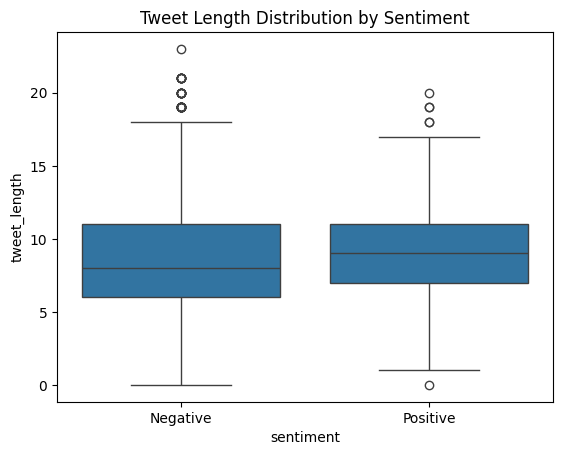

In [26]:
sns.boxplot(x='sentiment', y='tweet_length', data=df)
plt.title('Tweet Length Distribution by Sentiment')
plt.show()

In [27]:
from sklearn.feature_extraction.text import TfidfVectorizer

X = df['clean_tweet']
y = df['label']

tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2)
)

X_tfidf = tfidf.fit_transform(X)


In [28]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf, y, test_size=0.2, random_state=42
)


In [29]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)


LogisticRegression(max_iter=1000)

In [30]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
accuracy


0.9501016737056155

In [31]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.95      1.00      0.97      5937
           1       0.92      0.33      0.48       456

    accuracy                           0.95      6393
   macro avg       0.94      0.66      0.73      6393
weighted avg       0.95      0.95      0.94      6393



In [32]:
from sklearn.linear_model import LogisticRegression

model_balanced = LogisticRegression(
    max_iter=1000,
    class_weight='balanced'
)

model_balanced.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [33]:
from sklearn.metrics import classification_report

y_pred_balanced = model_balanced.predict(X_test)
print(classification_report(y_test, y_pred_balanced))


              precision    recall  f1-score   support

           0       0.98      0.92      0.95      5937
           1       0.45      0.81      0.57       456

    accuracy                           0.91      6393
   macro avg       0.72      0.87      0.76      6393
weighted avg       0.95      0.91      0.93      6393



In [34]:
y_prob = model_balanced.predict_proba(X_test)[:, 1]


In [35]:
import numpy as np

y_pred_threshold = np.where(y_prob >= 0.3, 1, 0)
print(classification_report(y_test, y_pred_threshold))


              precision    recall  f1-score   support

           0       0.99      0.82      0.90      5937
           1       0.27      0.90      0.42       456

    accuracy                           0.82      6393
   macro avg       0.63      0.86      0.66      6393
weighted avg       0.94      0.82      0.86      6393



In [36]:
from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)

y_pred_nb = nb_model.predict(X_test)
print(classification_report(y_test, y_pred_nb))


              precision    recall  f1-score   support

           0       0.95      1.00      0.97      5937
           1       0.91      0.34      0.49       456

    accuracy                           0.95      6393
   macro avg       0.93      0.67      0.73      6393
weighted avg       0.95      0.95      0.94      6393

